# Progetto Machine Learning: Cupid's Algorithm

In questo notebook costruiamo un modello di **regressione** che prova a prevedere il punteggio di compatibilità (`compatibility_score`) tra due persone (Persona A e Persona B), partendo dai loro dati anagrafici e dai loro tratti di personalità.

Il percorso è diviso in questi passaggi:

1. Importare i dati
2. Osservare il dataset (quick look)
3. Train/test split (eseguito prima di ogni analisi approfondita, per evitare data leakage)
4. Data Exploration e creazione di nuove variabili (feature di coppia: differenze tra i tratti e variabili di somiglianza)
5. Data preprocessing e Pipeline di elaborazione
6. Definizione e Addestramento del modello (Rete Neurale, MLPRegressor)
7. Learning curve e validazione interna
8. Valutazione sul Test Set (RMSE)
9. Confronto con un Decision Tree Regressor, con Ottimizzazione degli Iperparametri (GridSearchCV)
10. Visualizzazione della struttura dell'albero
11. Valutazione finale comparativa: Rete Neurale vs Decision Tree (RMSE, MAE, R²

# 1. Importare i dati

In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=6)
plt.rc('axes', labelsize=6, titlesize=6)
plt.rc('legend', fontsize=6)
plt.rc('xtick', labelsize=6)
plt.rc('ytick', labelsize=6)

In [4]:

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [5]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("likithagedipudi/cupids-algorithm")

print("Path to dataset files:", path)
print("Archivos:", os.listdir(path))
archivio = os.listdir(path)
csv_path = os.path.join(path, archivio[0])

100%|██████████| 4.02M/4.02M [00:01<00:00, 3.04MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/likithagedipudi/cupids-algorithm/versions/1
Archivos: ['cupid_algorithm_dataset.csv']


# 2. Osservare il dataset

Ciascuna riga rappresenta una coppia di individui (Persona A e Persona B) con 13 caratteristiche per persona, distribuite su 7 dimensioni.

* **Personality:** Tratti dei Big Five (apertura mentale, estroversione,
gradevolezza e coscienziosità), che descrivono il profilo psicologico. (noto anche con l'acronimo inglese OCEAN):O - Apertura all'esperienza (Openness): Curiosità, creatività e predisposizione verso nuove idee.C - Coscienziosità (Conscientiousness): Autocontrollo, precisione, affidabilità e orientamento agli obiettivi.E - Estroversione (Extraversion): Livello di energia, socievolezza e ricerca di stimoli esterni.A - Amicalità o Piacevolezza (Agreeableness): Altruismo, fiducia, empatia e capacità di cooperare.N - Nevroticismo o Stabilità Emotiva (Neuroticism): Tendenza a provare emozioni negative come ansia, instabilità e vulnerabilità
* **Career:** Settore professionale (10 settori) e livello di ambizione, che riflettono l'allineamento professionale.
* **Lifestyle:** Cronotipo (da nottambulo a mattiniero) e grado di spontaneità (da pianificatore a spirito libero).
* **Communication:** Espressività emotiva, che misura quanto apertamente gli individui condividono i propri sentimenti.
* **Love Language:** Modalità preferita di esprimere e ricevere affetto: Words of Affirmation, Acts of Service, Receiving Gifts, Quality Time oppure Physical Touch.
* **Demographics:** Età (18–55 anni), livello di istruzione (Scuola superiore → Dottorato) e tipologia di residenza (urbana, suburbana o rurale).


Ogni riga del dataset rappresenta una coppia di individui (Persona A e Persona B). Per ciascuna persona sono disponibili 13 caratteristiche, raggruppate in 7 dimensioni principali.

* **Personality:** Profilo psicologico basato sul modello dei Big Five (OCEAN), uno dei framework più utilizzati nella psicologia della personalità:
O – Openness to Experience (Apertura all'esperienza): curiosità, creatività e predisposizione verso nuove idee ed esperienze.
C – Conscientiousness (Coscienziosità): autodisciplina, affidabilità, precisione e orientamento agli obiettivi.
E – Extraversion (Estroversione): socievolezza, livello di energia e ricerca di interazioni sociali.
A – Agreeableness (Amicalità): empatia, cooperazione, fiducia e propensione all'altruismo.
N – Neuroticism (Nevroticismo): tendenza a sperimentare emozioni negative come ansia, instabilità emotiva e vulnerabilità allo stress.
* **Career:**  Informazioni sul percorso professionale, comprendenti il settore lavorativo (10 categorie) e il livello di ambizione, utilizzati per descrivere l'affinità professionale.
* **Lifestyle:** Abitudini e stile di vita, inclusi il cronotipo (da mattiniero a nottambulo) e il grado di spontaneità (da pianificatore a spirito libero).
* **Communication:** Livello di espressività emotiva, che indica quanto una persona tende a comunicare apertamente emozioni e sentimenti.
* **Love Language:** Linguaggio dell'amore predominante, ovvero la modalità preferita di esprimere e ricevere affetto secondo il modello delle Five Love Languages: Words of Affirmation, Acts of Service, Receiving Gifts, Quality Time e Physical Touch.
* **Demographics:** Caratteristiche demografiche della persona, tra cui età (18–55 anni), livello di istruzione (dalla scuola superiore al dottorato) e tipologia di residenza (urbana, suburbana o rurale).

In [6]:
df = pd.read_csv(csv_path)
df.head()

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontaneity                  100000 non-null  float64
 12  a_love_language                

**Cosa abbiamo ottenuto:** Nessun valore mancante o null

In [8]:
df.describe()

,pair_id,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,...,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,36.558140,2.951980,0.496463,0.499959,0.500131,0.501397,0.498643,0.499697,0.500012,...,0.499897,0.499177,0.500100,0.500063,0.500779,0.500324,0.500310,63.122273,0.428810,68.906250
std,28867.657797,10.951788,1.117733,0.174898,0.223607,0.224783,0.223860,0.223444,0.224779,0.226265,...,0.223567,0.223989,0.223253,0.223312,0.224214,0.226398,0.225954,10.705780,0.494909,21.334574
min,1.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.500000,0.000000,0.000000
25%,25000.750000,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.320000,0.330000,0.330000,...,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,0.330000,55.900000,0.000000,54.000000
50%,50000.500000,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,63.000000,0.000000,69.000000
75%,75000.250000,46.000000,4.000000,0.620000,0.670000,0.670000,0.680000,0.670000,0.670000,0.670000,...,0.670000,0.670000,0.670000,0.670000,0.680000,0.680000,0.670000,70.300000,1.000000,83.000000
max,100000.000000,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,120.000000


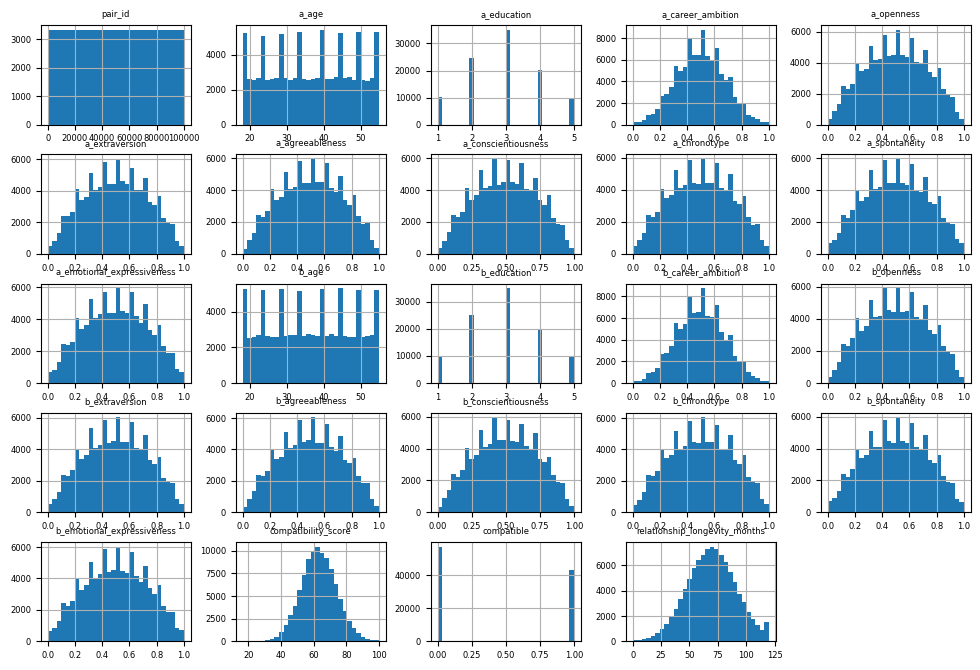

In [9]:
df.hist(bins=30, figsize=(12, 8))

plt.show()

# 3. Train/test split

Il dataset viene suddiviso in questo punto del workflow, dopo una prima esplorazione generale dei dati (head(), info(), describe(), distribuzioni e istogrammi) e prima di qualsiasi analisi che coinvolga la relazione tra feature e target (ad esempio analisi delle correlazioni, selezione delle variabili o feature engineering).

Da questa fase in poi, tutte le operazioni vengono effettuate esclusivamente su una copia del training set. Questa scelta permette di mantenere il test set completamente isolato durante le attività di esplorazione e preparazione dei dati, evitando che informazioni provenienti dal test possano influenzare le decisioni di modellazione.

In questo modo si previene il fenomeno del data leakage, ovvero l'introduzione involontaria di informazioni non disponibili al modello in fase di predizione reale, che potrebbe portare a una stima artificiosamente ottimistica delle performance.

In [10]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

df = train_set.copy()

#4. Data Exploration e creazione di nuove variabili

**Analisi delle feature rispetto al target**

Il target del problema di regressione è il **compatibility_score**, ovvero il punteggio di compatibilità assegnato alla coppia.

Per analizzare quali caratteristiche influenzano maggiormente questo valore, viene calcolato il coefficiente di correlazione di Pearson tra le feature disponibili e il target. Tuttavia, poiché il dataset descrive relazioni tra coppie di individui e non persone singole, la compatibilità non può essere spiegata considerando il profilo assoluto di un solo individuo, ma deve essere valutata in funzione della dinamica tra i due partner.

Per questo motivo, le caratteristiche originali delle due persone vengono trasformate in nuove feature relazionali, progettate per rappresentare il grado di somiglianza o differenza tra i membri della coppia. In particolare:

per le variabili numeriche (ad esempio i tratti di personalità) vengono calcolate differenze assolute tra Persona A e Persona B, così da misurare la distanza tra i rispettivi profili;
per le variabili categoriche vengono creati indicatori binari di uguaglianza, che segnalano se i due individui condividono la stessa categoria o presentano caratteristiche diverse.

Questa trasformazione consente di passare da feature individuali a feature di compatibilità, rendendo l'analisi della correlazione più coerente con il problema studiato.

La correlazione viene quindi calcolata tra le caratteristiche della relazione e il compatibility_score, permettendo di identificare quali aspetti della coppia contribuiscono ad aumentare o ridurre il livello di compatibilità previsto dal modello.

In [11]:
df["openness_diff"] = abs(df["a_openness"] - df["b_openness"])
df["career_ambition_diff"] = abs(df["a_career_ambition"] - df["b_career_ambition"])
df["extraversion_diff"] = abs(df["a_extraversion"] - df["b_extraversion"])
df["agreeableness_diff"] = abs(df["a_agreeableness"] - df["b_agreeableness"])
df["conscientiousness_diff"] = abs(df["a_conscientiousness"] - df["b_conscientiousness"])
df["chronotype_diff"] = abs(df["a_chronotype"] - df["b_chronotype"])
df["spontaneity_diff"] = abs(df["a_spontaneity"] - df["b_spontaneity"])
df["age_diff"] = abs(df["a_age"] - df["b_age"])
df["emotional_expressiveness_diff"] = abs(df["a_emotional_expressiveness"] - df["b_emotional_expressiveness"])
df["education_diff"] = abs(df["a_education"] - df["b_education"])


**Analisi delle variabili categoriche di coppia**

Oltre all'analisi della relazione tra le feature numeriche e il compatibility_score, è necessario valutare anche il ruolo delle variabili categoriche condivise all'interno della coppia, come ad esempio il Love Language, il contesto abitativo e il settore lavorativo.

Poiché queste caratteristiche non rappresentano valori continui, non è possibile applicare direttamente una correlazione numerica. Per questo motivo, le variabili categoriche vengono trasformate in feature relazionali che descrivono il livello di similarità tra i due individui.

In particolare, per ciascuna variabile categorica viene introdotto un indicatore di matching, che assume valore:

1 se Persona A e Persona B condividono la stessa categoria;
0 se appartengono a categorie differenti.

Queste nuove feature permettono di misurare se la condivisione di determinate caratteristiche all'interno della coppia è associata a un aumento o a una diminuzione del compatibility_score.

L'analisi consente quindi di identificare non solo l'effetto delle differenze nei tratti numerici, ma anche il ruolo della compatibilità categoriale, ovvero quanto la presenza di interessi, abitudini o contesti comuni possa contribuire alla qualità della relazione.

In [12]:
df["same_love_language"] = (
    df["a_love_language"] == df["b_love_language"]
).astype(int)

df["same_location"] = (
    df["a_location"] == df["b_location"]
).astype(int)

df["same_career"] = (
    df["a_career_field"] == df["b_career_field"]
).astype(int)



In [13]:
compatibility_features = [
    "age_diff",
    "education_diff",
    "career_ambition_diff",
    "openness_diff",
    "conscientiousness_diff",
    "extraversion_diff",
    "agreeableness_diff",
    "same_location",
    "same_career",
    "same_love_language"
]

corr = (
    df[compatibility_features]
      .corrwith(df["compatibility_score"])
      .sort_values(ascending=False)
)

corr = corr.to_frame(name="Pearson correlation")

print(corr)



                        Pearson correlation
same_love_language                 0.376429
same_career                        0.093638
same_location                      0.069708
age_diff                          -0.057268
agreeableness_diff                -0.081114
conscientiousness_diff            -0.085250
education_diff                    -0.086083
extraversion_diff                 -0.126357
openness_diff                     -0.129238
career_ambition_diff              -0.285526


Il coefficiente di correlazione di Pearson varia tra -1 e +1:

* valori vicini a +1 indicano una relazione lineare positiva;
* valori vicini a 0 indicano l'assenza di una relazione lineare;
*valori vicini a -1 indicano una relazione lineare negativa.

Dalla tabella emerge che l'unica variabile con una correlazione positiva, anche se debole, con il Compatibility Score è la condivisione dello stesso Love Language.

La maggior parte dei coefficienti risulta invece negativa: questo indica che all'aumentare della differenza tra le caratteristiche dei due partner, il punteggio di compatibilità tende a diminuire. In particolare, maggiore è la distanza tra i profili della coppia, minore tende a essere la compatibilità stimata. Tuttavia, i valori dei coefficienti sono generalmente molto bassi, quindi la relazione lineare osservata è poco significativa.

Le due variabili che mostrano la relazione più evidente con il target sono:

* la condivisione dello stesso Love Language;
* la differenza nel livello di ambizione lavorativa.

Nel complesso, i risultati indicano che il Compatibility Score non dipende da una singola caratteristica, ma probabilmente dalla combinazione di più variabili e dalle loro interazioni.

Per questo motivo, il coefficiente di Pearson verrà confrontato con quello di Spearman, che valuta la relazione basandosi sui ranghi delle variabili. Questo permetterà di verificare se esistono correlazioni monotone non necessariamente lineari, che Pearson potrebbe non rilevare.

In [14]:
pearson = df[compatibility_features].corrwith(
    df["compatibility_score"],
    method="pearson"
)

spearman = df[compatibility_features].corrwith(
    df["compatibility_score"],
    method="spearman"
)

results = pd.DataFrame({
    "Feature": compatibility_features,
    "Pearson (r)": pearson.values,
    "Spearman (ρ)": spearman.values
})


from scipy.stats import pearsonr, spearmanr
import pandas as pd

results = []

for feature in compatibility_features:

    # Pearson
    r, p_pearson = pearsonr(
        df[feature],
        df["compatibility_score"]
    )

    # Spearman
    rho, p_spearman = spearmanr(
        df[feature],
        df["compatibility_score"]
    )

    results.append({
        "Feature": feature,
        "Pearson (r)": r,
        "Spearman (ρ)": rho,
        "p-value Pearson": p_pearson,
        "p-value Spearman": p_spearman
    })


final_results = pd.DataFrame(results)

final_results

,Feature,Pearson (r),Spearman (ρ),p-value Pearson,p-value Spearman
0,age_diff,-0.057268,-0.060742,4.223851e-59,2.837856e-66
1,education_diff,-0.086083,-0.078655,2.032432e-131,5.633444e-110
2,career_ambition_diff,-0.285526,-0.275774,0.000000e+00,0.000000e+00
3,openness_diff,-0.129238,-0.116680,5.520816e-295,1.822542e-240
4,conscientiousness_diff,-0.085250,-0.079440,6.447023e-129,3.762569e-112
5,extraversion_diff,-0.126357,-0.113205,5.716198e-282,2.180467e-226
6,agreeableness_diff,-0.081114,-0.070951,7.378750e-117,8.510847e-90
7,same_location,0.069708,0.068074,9.756133e-87,8.498211e-83
8,same_career,0.093638,0.091160,3.108855e-155,3.384690e-147
9,same_love_language,0.376429,0.365351,0.000000e+00,0.000000e+00


Il confronto tra i coefficienti di **Pearson** e **Spearman** mostra risultati molto simili, indicando che le relazioni osservate con il Compatibility Score sono abbastanza stabili e non dipendono esclusivamente dalla linearità dei dati.

I **p-value** calcolati per entrambe le correlazioni risultano statisticamente significativi (p < 0.001) per tutte le variabili analizzate. Tuttavia, la significatività statistica è probabilmente influenzata dalla dimensione elevata del campione: le correlazioni risultano infatti significative, ma con una magnitudine generalmente debole.

Tra le variabili analizzate, la maggiore associazione positiva con il compatibility_score è osservata per **same_love_language**, mentre **career_ambition_diff** presenta la relazione negativa più forte. Questo suggerisce che la condivisione del linguaggio dell'amore può avere un effetto positivo sulla compatibilità, mentre differenze elevate nell'ambizione professionale possono essere associate a punteggi di compatibilità inferiori.

Nel complesso, i risultati confermano che nessuna singola variabile è sufficiente a spiegare il punteggio di compatibilità, che sembra dipendere dalla combinazione di più caratteristiche della coppia.

#  5. Data preprocessing e Pipeline di elaborazione

**Ricostruzione delle feature relazionali sul test set**

Durante lo split iniziale, il test set è stato mantenuto separato e non è stato utilizzato nella fase di analisi e costruzione delle feature. Di conseguenza, non contiene ancora le variabili derivate create sul training set, come le feature di differenza (_diff) e gli indicatori di uguaglianza (same_*).

Prima della valutazione del modello, queste feature vengono ricreate anche sul test set utilizzando lo stesso identico processo applicato al train set. In questo modo, entrambi i dataset mantengono la stessa struttura e il modello riceve in input feature coerenti durante la fase di predizione.

Questa procedura permette di evitare discrepanze tra train e test set e garantisce una valutazione corretta delle performance del modello.

In [15]:
test_set["openness_diff"] = abs(test_set["a_openness"] - test_set["b_openness"])
test_set["career_ambition_diff"] = abs(test_set["a_career_ambition"] - test_set["b_career_ambition"])
test_set["extraversion_diff"] = abs(test_set["a_extraversion"] - test_set["b_extraversion"])
test_set["agreeableness_diff"] = abs(test_set["a_agreeableness"] - test_set["b_agreeableness"])
test_set["conscientiousness_diff"] = abs(test_set["a_conscientiousness"] - test_set["b_conscientiousness"])
test_set["chronotype_diff"] = abs(test_set["a_chronotype"] - test_set["b_chronotype"])
test_set["spontaneity_diff"] = abs(test_set["a_spontaneity"] - test_set["b_spontaneity"])
test_set["age_diff"] = abs(test_set["a_age"] - test_set["b_age"])
test_set["emotional_expressiveness_diff"] = abs(test_set["a_emotional_expressiveness"] - test_set["b_emotional_expressiveness"])
test_set["education_diff"] = abs(test_set["a_education"] - test_set["b_education"])

test_set["same_love_language"] = (
    test_set["a_love_language"] == test_set["b_love_language"]
).astype(int)

test_set["same_location"] = (
    test_set["a_location"] == test_set["b_location"]
).astype(int)

test_set["same_career"] = (
    test_set["a_career_field"] == test_set["b_career_field"]
).astype(int)

**Separazione di X e y per train e test**

Prima dell'addestramento del modello, il dataset viene suddiviso in feature (X) e target (y).

Dalle variabili di input vengono rimosse le colonne che non devono essere utilizzate dal modello:

pair_id, in quanto rappresenta solamente un identificativo della coppia e non contiene informazione predittiva;
compatible e relationship_longevity_months, perché sono variabili target alternative che, se incluse tra le feature, fornirebbero al modello informazioni direttamente correlate al risultato da prevedere, causando data leakage.

In questo modo, il modello utilizza esclusivamente le caratteristiche disponibili a priori della coppia per stimare il compatibility_score, garantendo una valutazione corretta delle sue capacità predittive.

In [16]:
train_set = df  # df contiene ora tutte le feature aggiunte durante l'EDA

escludere = ["pair_id", "compatible", "compatibility_score", "relationship_longevity_months"]

X_train = train_set.drop(escludere, axis=1)
y_train = train_set["compatibility_score"]

X_test = test_set.drop(escludere, axis=1)
y_test = test_set["compatibility_score"]

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   a_age                          80000 non-null  int64  
 1   a_education                    80000 non-null  int64  
 2   a_location                     80000 non-null  object 
 3   a_career_field                 80000 non-null  object 
 4   a_career_ambition              80000 non-null  float64
 5   a_openness                     80000 non-null  float64
 6   a_extraversion                 80000 non-null  float64
 7   a_agreeableness                80000 non-null  float64
 8   a_conscientiousness            80000 non-null  float64
 9   a_chronotype                   80000 non-null  float64
 10  a_spontaneity                  80000 non-null  float64
 11  a_love_language                80000 non-null  object 
 12  a_emotional_expressiveness     80000 non-null  

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = [
    "a_age", "a_education", "a_career_ambition",
    "a_openness", "a_extraversion", "a_agreeableness", "a_conscientiousness",
    "a_chronotype", "a_spontaneity", "a_emotional_expressiveness",
    "b_age", "b_education", "b_career_ambition",
    "b_openness", "b_extraversion", "b_agreeableness", "b_conscientiousness",
    "b_chronotype", "b_spontaneity", "b_emotional_expressiveness",
    "openness_diff", "career_ambition_diff", "extraversion_diff",
    "agreeableness_diff", "conscientiousness_diff", "chronotype_diff",
    "spontaneity_diff", "age_diff", "emotional_expressiveness_diff", "education_diff",
    "same_love_language", "same_location", "same_career"
]

cat_features = [
    "a_location", "a_career_field", "a_love_language",
    "b_location", "b_career_field", "b_love_language"
]

preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# 6. Definizione e Addestramento del modello (Rete Neurale, MLPRegressor)

In [18]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(100, 50), early_stopping=True,
                       verbose=True, random_state=42)

In [19]:
pipeline = make_pipeline(preprocessing, mlp_reg)
pipeline.fit(X_train, y_train)

Iteration 1, loss = 324.70401393
Validation score: 0.331829
Iteration 2, loss = 36.88502987
Validation score: 0.357105
Iteration 3, loss = 35.66029514
Validation score: 0.370548
Iteration 4, loss = 34.96984651
Validation score: 0.380591
Iteration 5, loss = 34.52193233
Validation score: 0.386293
Iteration 6, loss = 34.07859526
Validation score: 0.390871
Iteration 7, loss = 33.54090871
Validation score: 0.397670
Iteration 8, loss = 33.22493390
Validation score: 0.398948
Iteration 9, loss = 33.12117851
Validation score: 0.403027
Iteration 10, loss = 32.95913377
Validation score: 0.405279
Iteration 11, loss = 32.85556411
Validation score: 0.404545
Iteration 12, loss = 32.80450254
Validation score: 0.405421
Iteration 13, loss = 32.67165397
Validation score: 0.404727
Iteration 14, loss = 32.60802350
Validation score: 0.391473
Iteration 15, loss = 32.53402524
Validation score: 0.407551
Iteration 16, loss = 32.50250288
Validation score: 0.403165
Iteration 17, loss = 32.37966448
Validation scor

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['a_age', 'a_education',
                                                   'a_career_ambition',
                                                   'a_openness',
                                                   'a_extraversion',
                                                   'a_agreeableness',
                                                   'a_conscientiousness',
                                                   'a_chronotype',
                                                   'a_spontaneity',
                                                   'a_emotional_expressiveness',
                                                   'b_age', 'b_education',
                                                   'b_career_ambition',
                                                   'b_openness',
                                                   'b_extraversion',
                                                   'b_agreeable...
                                                   'chronotype_diff',
                                                   'spontaneity_diff',
                                                   'age_diff',
                                                   'emotional_expressiveness_diff',
                                                   'education_diff', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['a_location',
                                                   'a_career_field',
                                                   'a_love_language',
                                                   'b_location',
                                                   'b_career_field',
                                                   'b_love_language'])])),
                ('mlpregressor',
                 MLPRegressor(early_stopping=True, hidden_layer_sizes=(100, 50),
                              random_state=42, verbose=True))])

#7. Learning curve e validazione interna

La loss_curve_ mostra l'andamento della funzione di errore (loss) durante le diverse iterazioni dell'addestramento del modello.

Un comportamento ideale è rappresentato da una progressiva diminuzione della loss, che indica che il modello sta migliorando la capacità di adattarsi ai dati di training.

Con l'impostazione early_stopping=True, Scikit-Learn utilizza una parte del training set come validation set interno per monitorare le performance durante l'addestramento. Il processo di training viene interrotto automaticamente quando il modello non mostra più miglioramenti significativi, riducendo il rischio di overfitting e ottimizzando il numero di iterazioni necessarie.

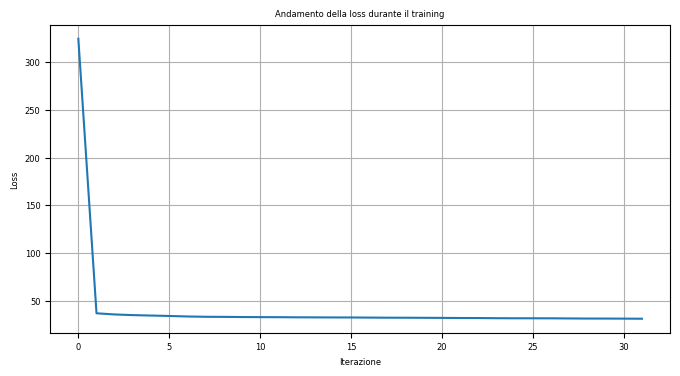

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.loss_curve_)
plt.xlabel("Iterazione")
plt.ylabel("Loss")
plt.title("Andamento della loss durante il training")
plt.grid(True)
plt.show()

**Andamento sul validation set**

Con early_stopping=True, Scikit-Learn monitora durante l'addestramento anche le performance del modello su un validation set interno, ricavato dal training set.

L'andamento dello score sul validation set permette di valutare se il modello sta effettivamente migliorando su dati non utilizzati direttamente per l'aggiornamento dei pesi.

Una crescita dello score indica un miglioramento della capacità di generalizzazione, mentre un calo o una stabilizzazione dopo un certo numero di iterazioni può indicare l'inizio di overfitting. Questa informazione viene utilizzata dall'algoritmo per interrompere automaticamente il training nel punto più efficace.

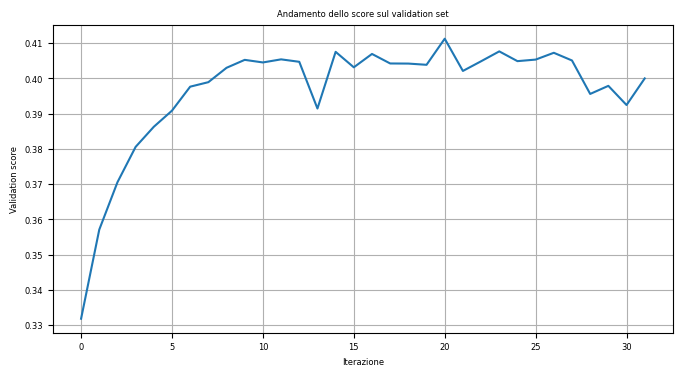

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.validation_scores_)
plt.xlabel("Iterazione")
plt.ylabel("Validation score")
plt.title("Andamento dello score sul validation set")
plt.grid(True)
plt.show()

**Miglior punteggio sul validation set**

La metrica best_validation_score_ rappresenta il miglior punteggio ottenuto dal modello sul validation set interno durante il processo di addestramento.

Questo valore permette di verificare quale sia stata la migliore performance raggiunta prima dell'interruzione automatica tramite early stopping e fornisce un'indicazione sulla capacità del modello di generalizzare su dati non utilizzati direttamente per l'ottimizzazione dei pesi.

Il confronto con le performance ottenute successivamente sul test set permette di valutare se il modello mantiene un comportamento coerente su dati completamente nuovi.

In [22]:
mlp_reg.best_validation_score_

0.41127614179763805

# 8. Valutazione sul Test Set (RMSE)
Il modello viene valutato sul test set utilizzando la metrica **RMSE (Root Mean Squared Error)**.

L'RMSE misura la distanza media tra i valori predetti dal modello e i valori reali del compatibility_score. Rispetto al MSE, risulta più interpretabile perché è espresso nella stessa unità di misura del target.

Un valore di RMSE più basso indica una maggiore accuratezza del modello, ovvero una minore differenza tra le predizioni e i valori effettivi osservati nel test set.

In [23]:
y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

8.149145916777055

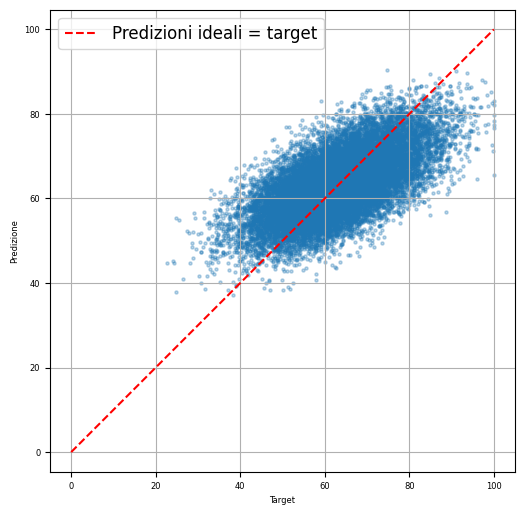

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=5, alpha=0.3)
plt.plot([0, 100], [0, 100], color='red', linestyle='--',
         label="Predizioni ideali = target")
plt.axis("equal")
plt.xlabel("Target")
plt.ylabel("Predizione")
plt.legend(fontsize=12)
plt.grid()

plt.show()

# 9. Confronto con un Decision Tree Regressor, con Ottimizzazione degli Iperparametri (GridSearchCV)

**Import e definizione della pipeline con Decision Tree**

**Pipeline di preprocessing**

Per il secondo modello viene utilizzata la stessa pipeline di preprocessing applicata all'MLP, composta da:

StandardScaler per la normalizzazione delle variabili numeriche;
OneHotEncoder per la trasformazione delle variabili categoriche in formato numerico.

Mantenere lo stesso processo di preparazione dei dati permette un confronto corretto tra i modelli, assicurando che entrambi ricevano in input le stesse feature trasformate con le medesime procedure.

In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

tree_pipeline = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))

**Ottimizzazione della complessità del Decision Tree**

Per ridurre la complessità del modello vengono definite diverse combinazioni di iperparametri da testare tramite GridSearchCV.

Questa fase è necessaria perché un Decision Tree non vincolato tende facilmente a memorizzare i dati di training, generando overfitting e scarsa capacità di generalizzazione su nuovi dati.

GridSearchCV valuta ogni combinazione di parametri utilizzando una cross-validation a 3 fold:

il training set viene suddiviso in 3 parti;

*   il modello viene allenato su 2 parti e validato sulla terza;
*   il processo viene ripetuto ruotando il ruolo delle tre sezioni;
* viene selezionata la configurazione con la migliore performance media.

Tutta la ricerca degli iperparametri viene effettuata esclusivamente all'interno del training set. Il test set rimane completamente isolato e viene utilizzato solo nella fase finale di valutazione del modello, evitando qualsiasi forma di data leakage.

In [26]:
params = {
    'decisiontreeregressor__max_leaf_nodes': list(range(5, 50, 5)),   # numero massimo di foglie finali
    'decisiontreeregressor__max_depth': [1, 2, 3, 4, 5, 6],         # profondità massima dell'albero
    'decisiontreeregressor__min_samples_split': [2, 3, 4]           # minimo di righe per poter dividere un nodo
}

grid_search_cv = GridSearchCV(
    tree_pipeline,
    params,
    cv=3,
    scoring="neg_root_mean_squared_error",  # usiamo la stessa metrica (RMSE) del resto del progetto
     n_jobs=-1 )

grid_search_cv.fit(X_train, y_train)

print("Migliori parametri trovati:", grid_search_cv.best_params_)

Migliori parametri trovati: {'decisiontreeregressor__max_depth': 6, 'decisiontreeregressor__max_leaf_nodes': 45, 'decisiontreeregressor__min_samples_split': 2}


**valutazione sul test set**

In [27]:
best_tree = grid_search_cv.best_estimator_

y_pred_tree = best_tree.predict(X_test)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)

print(f"RMSE Decision Tree (test): {rmse_tree:.3f}")
print(f"RMSE rete neurale MLP (test): {rmse:.3f}")  # rmse è già calcolato dalla sezione MLP

RMSE Decision Tree (test): 8.957
RMSE rete neurale MLP (test): 8.149


#10. Visualizzazione della struttura dell'albero

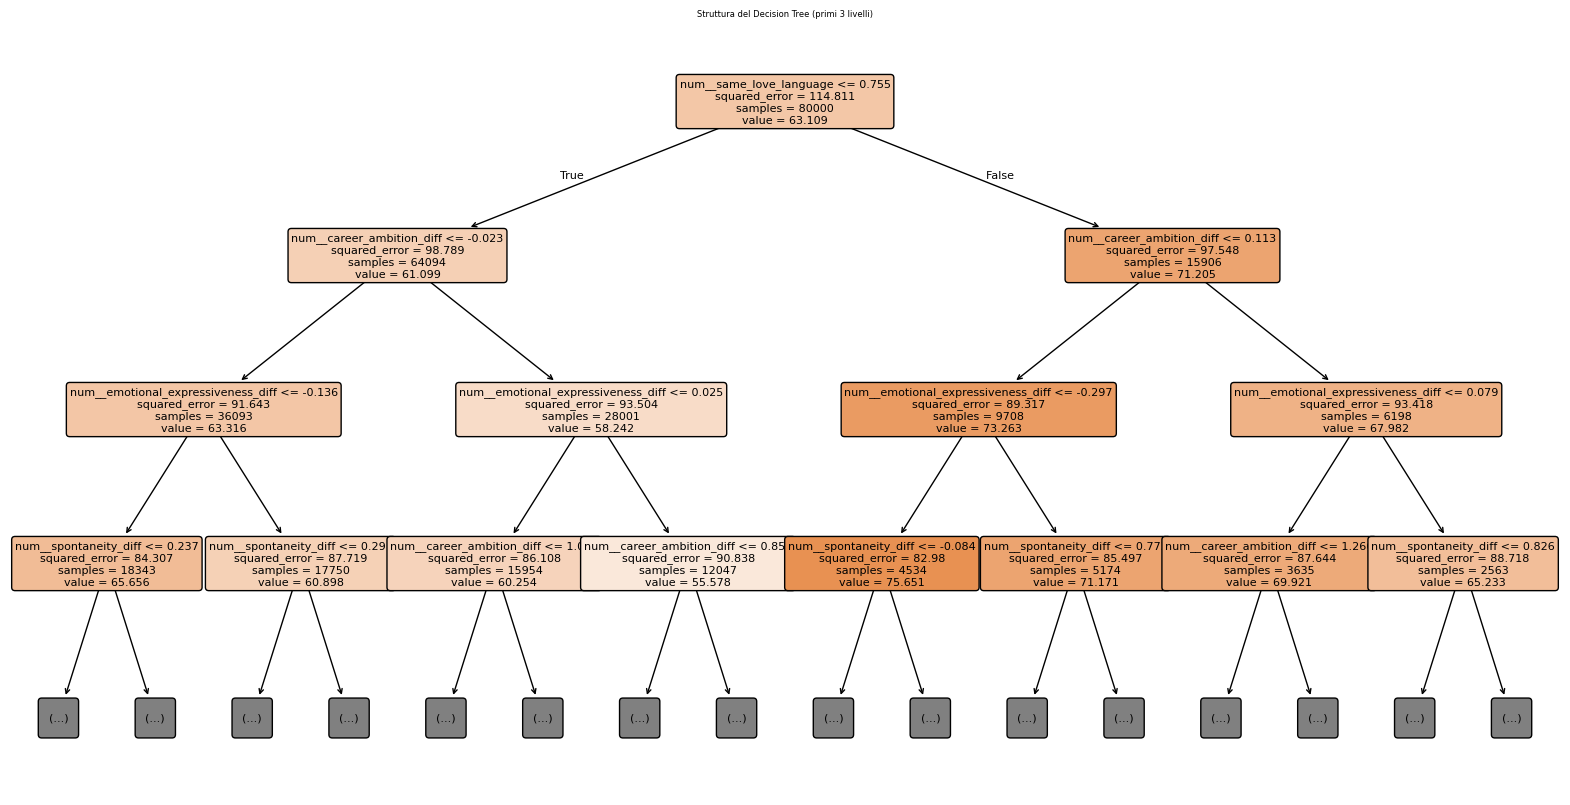

In [28]:
from sklearn.tree import plot_tree

tree_model = best_tree.named_steps["decisiontreeregressor"]

feature_names = best_tree.named_steps["columntransformer"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Struttura del Decision Tree (primi 3 livelli)")
plt.show()

**Scatter plot predizioni vs target, come hai già per l'MLP**

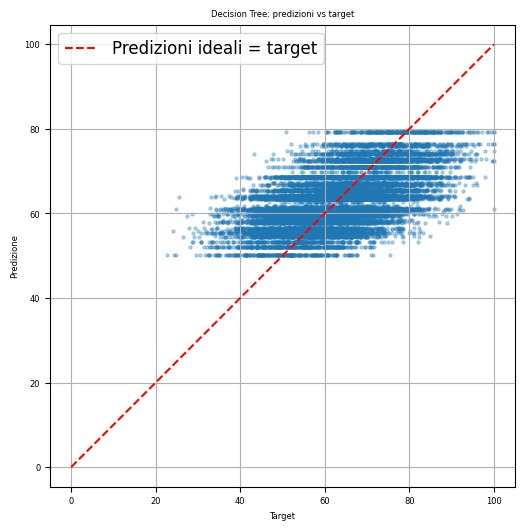

In [29]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_tree, s=5, alpha=0.3)
plt.plot([0, 100], [0, 100], color='red', linestyle='--',
         label="Predizioni ideali = target")
plt.axis("equal")
plt.xlabel("Target")
plt.ylabel("Predizione")
plt.title("Decision Tree: predizioni vs target")
plt.legend(fontsize=12)
plt.grid()
plt.show()

# 11. Valutazione finale comparativa: Rete Neurale vs Decision Tree (RMSE, MAE, R²)

In [30]:
from sklearn.metrics import mean_absolute_error, r2_score

# Per l'MLP
mae_mlp = mean_absolute_error(y_test, y_pred)
r2_mlp = r2_score(y_test, y_pred)

# Per il Decision Tree
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"{'Metrica':<10}{'MLP':>10}{'Decision Tree':>18}")
print(f"{'RMSE':<10}{rmse:>10.3f}{rmse_tree:>18.3f}")
print(f"{'MAE':<10}{mae_mlp:>10.3f}{mae_tree:>18.3f}")
print(f"{'R²':<10}{r2_mlp:>10.3f}{r2_tree:>18.3f}")

Metrica          MLP     Decision Tree
RMSE           8.149             8.957
MAE            6.497             7.130
R²             0.417             0.295


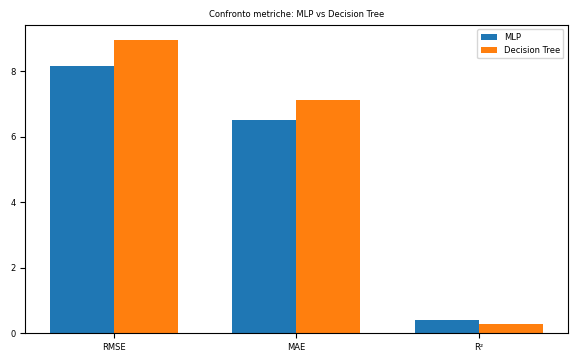

In [31]:
import numpy as np

metriche = ['RMSE', 'MAE', 'R²']
valori_mlp = [rmse, mae_mlp, r2_mlp]
valori_tree = [rmse_tree, mae_tree, r2_tree]

x = np.arange(len(metriche))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, valori_mlp, width, label='MLP')
plt.bar(x + width/2, valori_tree, width, label='Decision Tree')
plt.xticks(x, metriche)
plt.legend()
plt.title("Confronto metriche: MLP vs Decision Tree")
plt.show()